### This document is for linking REDCap and TSQIC datasets, where each row represents an id+surgery.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Updated data

In [2]:
# Load the Excel file
file_path = "ICU_Admission_and_Important_Dates(wt.2024).xlsx" 
df_update = pd.read_excel(file_path, sheet_name=None)
df_update_1 = df_update["Sheet1"]  
df_update_1 

,Patient ID,Patient MRN,RAMQ (if necessary),icu admission,real operation date,real discharge date,cancer type,cancer history,date of death,Important notes,Additional important notes
0,1043,698231,NaN,0.0,2021-02-23,2021-03-01,esophagogastric junction adenocarcinoma,liver metastasis at time of surgery,NaT,NaN,HER2+
1,1113,5609270,NaN,0.0,2021-04-20,2021-05-05,esophageal squamous cell carcinoma,had operation for liver cancer in Feb. 2021,NaT,NaN,NaN
2,1122,5644505,NaN,0.0,2021-07-28,2021-08-13,esophageal squamous cell carcinoma,NaN,NaT,length of stay >= 14 days,NaN
3,1130,1103634,NaN,0.0,2021-08-31,2021-11-05,esophageal squamous cell carcinoma,prior esophageal squamous cell carcinoma in Ja...,NaT,NaN,NaN
4,1135,907477,NaN,1.0,2021-01-05,2021-01-23,esophagogastric junction adenocarcinoma,cardia adenocarcinoma in 2020,2021-01-23,length of stay >= 14 days,NaN
...,...,...,...,...,...,...,...,...,...,...,...
151,1681,5691716,NaN,NaN,NaT,NaT,esophageal squamous cell carcinoma,history of prostate cancer,NaT,ICU consult but patient not admitted to ICU,NaN
152,1683,5979118,NaN,NaN,NaT,NaT,esophagogastric junction carcinoma,NaN,NaT,NaN,NaN
153,1684,5955682,NaN,NaN,NaT,NaT,esophagogastric junction carcinoma,NaN,NaT,NaN,NaN
154,1688,1487343,NaN,NaN,NaT,NaT,esophageal adenocarcinoma,NaN,NaT,NaN,NaN


In [3]:
df_update_1["real_operation_date"] = pd.to_datetime(df_update_1["real operation date"])
df_update_1["real_discharge_date"] = pd.to_datetime(df_update_1["real discharge date"])
df_update_1

,Patient ID,Patient MRN,RAMQ (if necessary),icu admission,real operation date,real discharge date,cancer type,cancer history,date of death,Important notes,Additional important notes,real_operation_date,real_discharge_date
0,1043,698231,NaN,0.0,2021-02-23,2021-03-01,esophagogastric junction adenocarcinoma,liver metastasis at time of surgery,NaT,NaN,HER2+,2021-02-23,2021-03-01
1,1113,5609270,NaN,0.0,2021-04-20,2021-05-05,esophageal squamous cell carcinoma,had operation for liver cancer in Feb. 2021,NaT,NaN,NaN,2021-04-20,2021-05-05
2,1122,5644505,NaN,0.0,2021-07-28,2021-08-13,esophageal squamous cell carcinoma,NaN,NaT,length of stay >= 14 days,NaN,2021-07-28,2021-08-13
3,1130,1103634,NaN,0.0,2021-08-31,2021-11-05,esophageal squamous cell carcinoma,prior esophageal squamous cell carcinoma in Ja...,NaT,NaN,NaN,2021-08-31,2021-11-05
4,1135,907477,NaN,1.0,2021-01-05,2021-01-23,esophagogastric junction adenocarcinoma,cardia adenocarcinoma in 2020,2021-01-23,length of stay >= 14 days,NaN,2021-01-05,2021-01-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1681,5691716,NaN,NaN,NaT,NaT,esophageal squamous cell carcinoma,history of prostate cancer,NaT,ICU consult but patient not admitted to ICU,NaN,NaT,NaT
152,1683,5979118,NaN,NaN,NaT,NaT,esophagogastric junction carcinoma,NaN,NaT,NaN,NaN,NaT,NaT
153,1684,5955682,NaN,NaN,NaT,NaT,esophagogastric junction carcinoma,NaN,NaT,NaN,NaN,NaT,NaT
154,1688,1487343,NaN,NaN,NaT,NaT,esophageal adenocarcinoma,NaN,NaT,NaN,NaN,NaT,NaT


# TSQIC tabs merging

In [4]:
# Load the Excel file
file_path = "../Nisha/Complications_TSQIC_TC_13_02_2025.xlsx" 
df_tsqic = pd.read_excel(file_path, sheet_name=None)

# Display sheet names
print(df_tsqic.keys())

# Access specific sheets/tabs
df_tsqic_1 = df_tsqic["TSQIC-Complications"]  
df_tsqic_2 = df_tsqic["TSQIC-admission-discharge dates"] 
print(df_tsqic_1)
print(df_tsqic_2)

dict_keys(['TSQIC-Complications', 'TSQIC-admission-discharge dates'])
        id date (operation) ComplicationDate     System       Complication  \
0      817       2016-09-07       2016-09-08    Cardiac       Hypotension    
1      190       2016-09-07       2016-09-08    Cardiac  Atrial Arrhythmia   
2      817       2016-09-07       2016-09-09    Cardiac  Atrial Arrhythmia   
3      190       2016-09-07       2016-09-10  Pulmonary         Hemoptysis   
4      817       2016-09-07       2016-09-11    Cardiac       Hypertension   
...    ...              ...              ...        ...                ...   
1557  1705       2024-09-04       2024-09-10  Pulmonary        Atelactasis   
1558  1705       2024-09-04       2024-09-10    Pleural           Effusion   
1559  1705       2024-09-04       2024-09-11      Anast   Mucosal necrosis   
1560  1687       2024-09-08       2024-09-16    Pleural           Effusion   
1561  1687       2024-09-08       2024-09-16    Pleural  Hydropneumothor

In [5]:
# Standardize column names for merging
df_tsqic_1 = df_tsqic_1.rename(columns={"date (operation)": "operation_date", "Readmission":"readmission_30d"})
df_tsqic_2 = df_tsqic_2.rename(columns={"Date (operation)": "operation_date"})


# Convert operation_date to datetime for proper matching
df_tsqic_1["operation_date"] = pd.to_datetime(df_tsqic_1["operation_date"])
df_tsqic_1["ComplicationDate"] = pd.to_datetime(df_tsqic_1["ComplicationDate"])
df_tsqic_2["operation_date"] = pd.to_datetime(df_tsqic_2["operation_date"])
df_tsqic_2["DischargeDate"] = pd.to_datetime(df_tsqic_2["DischargeDate"])

In [6]:
df_tsqic_2[df_tsqic_2['id']==128]

,id,operation_date,DischargeDate
739,128,2020-01-14,2020-01-14
740,128,2021-02-07,2021-03-25
741,128,2021-02-27,2021-03-25
742,128,2021-02-02,2021-03-25
743,128,2020-11-27,2020-12-05


In [7]:
# Remove unusable columns
df_tsqic_1 = df_tsqic_1.drop(columns=['System', "Prolonged", "Comments"])
df_tsqic_1

,id,operation_date,ComplicationDate,Complication,Grade,GradeLetter,readmission_30d
0,817,2016-09-07,2016-09-08,Hypotension,1,I - No treatment,0
1,190,2016-09-07,2016-09-08,Atrial Arrhythmia,1,I - No treatment,0
2,817,2016-09-07,2016-09-09,Atrial Arrhythmia,2,II - New Medication,0
3,190,2016-09-07,2016-09-10,Hemoptysis,3,IIIa - Intervention,0
4,817,2016-09-07,2016-09-11,Hypertension,2,II - New Medication,0
...,...,...,...,...,...,...,...
1557,1705,2024-09-04,2024-09-10,Atelactasis,2,II - New Medication,0
1558,1705,2024-09-04,2024-09-10,Effusion,2,II - New Medication,0
1559,1705,2024-09-04,2024-09-11,Mucosal necrosis,3,IIIa - Intervention,0
1560,1687,2024-09-08,2024-09-16,Effusion,2,II - New Medication,0


In [8]:
df_tsqic_1_filtered = df_tsqic_1.drop_duplicates()
df_tsqic_1_filtered

,id,operation_date,ComplicationDate,Complication,Grade,GradeLetter,readmission_30d
0,817,2016-09-07,2016-09-08,Hypotension,1,I - No treatment,0
1,190,2016-09-07,2016-09-08,Atrial Arrhythmia,1,I - No treatment,0
2,817,2016-09-07,2016-09-09,Atrial Arrhythmia,2,II - New Medication,0
3,190,2016-09-07,2016-09-10,Hemoptysis,3,IIIa - Intervention,0
4,817,2016-09-07,2016-09-11,Hypertension,2,II - New Medication,0
...,...,...,...,...,...,...,...
1557,1705,2024-09-04,2024-09-10,Atelactasis,2,II - New Medication,0
1558,1705,2024-09-04,2024-09-10,Effusion,2,II - New Medication,0
1559,1705,2024-09-04,2024-09-11,Mucosal necrosis,3,IIIa - Intervention,0
1560,1687,2024-09-08,2024-09-16,Effusion,2,II - New Medication,0


In [9]:
df_tsqic_2

,id,operation_date,DischargeDate
0,1692,2024-09-16,NaT
1,1705,2024-09-04,NaT
2,1705,2024-09-11,NaT
3,1683,2024-09-03,2024-09-10
4,1722,2024-08-27,2024-09-03
...,...,...,...
1255,817,2016-09-07,2016-09-13
1256,668,2016-12-23,2017-01-19
1257,668,2016-11-10,2017-01-19
1258,668,2016-11-17,2017-01-19


In [10]:
# Keep the earliest operation_date for each (id, DischargeDate) group
df_tsqic_2_filtered = df_tsqic_2.loc[df_tsqic_2.groupby(["id", "DischargeDate"])["operation_date"].idxmin()]

# Reset index if needed
df_tsqic_2_filtered = df_tsqic_2_filtered.reset_index(drop=True)

df_tsqic_2_filtered

,id,operation_date,DischargeDate
0,37,2023-05-03,2023-05-06
1,44,2019-05-21,2019-05-23
2,55,2019-10-22,2019-10-28
3,76,2021-05-18,2021-05-25
4,78,2019-12-10,2019-12-12
...,...,...,...
864,1706,2024-07-17,2024-07-31
865,1712,2024-08-20,2024-08-28
866,1722,2024-08-27,2024-09-03
867,1748,2024-07-23,2024-07-30


In [11]:
#There are only 3 ids with duplicates -> so manual check is ok -> remove earlier discharge dates make more logical after manual check
print(df_tsqic_2_filtered[df_tsqic_2_filtered.duplicated(subset=['id', 'operation_date'], keep=False)])

df_tsqic_2_filtered2 = df_tsqic_2_filtered.loc[df_tsqic_2_filtered.groupby(["id", "operation_date"])["DischargeDate"].idxmax()]
df_tsqic_2_filtered2

       id operation_date DischargeDate
26    190     2016-09-07    2016-09-07
28    190     2016-09-07    2016-09-23
113   648     2016-09-21    2016-09-21
116   648     2016-09-21    2016-10-12
768  1549     2023-03-01    2022-03-08
769  1549     2023-03-01    2023-03-08


,id,operation_date,DischargeDate
0,37,2023-05-03,2023-05-06
1,44,2019-05-21,2019-05-23
2,55,2019-10-22,2019-10-28
3,76,2021-05-18,2021-05-25
6,78,2019-09-03,2020-09-10
...,...,...,...
864,1706,2024-07-17,2024-07-31
865,1712,2024-08-20,2024-08-28
866,1722,2024-08-27,2024-09-03
867,1748,2024-07-23,2024-07-30


In [12]:
# Get Patient IDs from df_update_1 that have non-null real_operation_date
valid_update_data = df_update_1.dropna(subset=['real_operation_date'])
update_patient_ids = valid_update_data['Patient ID'].unique()

non_matching_ids = []
matching_ids = []

for patient_id in update_patient_ids:
    # Get the real operation date from df_update_1
    real_date = valid_update_data[valid_update_data['Patient ID'] == patient_id]['real_operation_date'].iloc[0]
    
    # Get all operation dates for this ID from df_tsqic_1_filtered
    tsqic_dates = df_tsqic_1_filtered[df_tsqic_1_filtered['id'] == patient_id]['operation_date'].values
    
    # Check if there's at least one match
    if len(tsqic_dates) > 0 and real_date in tsqic_dates:
        matching_ids.append(patient_id)
    else:
        non_matching_ids.append(patient_id)

print(f"Non-matching IDs: {non_matching_ids}")
print(f"Total non-matching IDs: {len(non_matching_ids)}")
print(f"Total matching IDs: {len(matching_ids)}")
print(f"Total valid Patient IDs checked: {len(update_patient_ids)}")

Non-matching IDs: [1241, 1508, 1633]
Total non-matching IDs: 3
Total matching IDs: 131
Total valid Patient IDs checked: 134


In [13]:
# Merge df_tsqic_1_filtered and df_tsqic_2_filtered2 on 'id' and 'operation_date'
tsqic_merged = pd.merge(df_tsqic_1_filtered, df_tsqic_2_filtered2, on=["id", "operation_date"], how="outer")


tsqic_merged = tsqic_merged.sort_values(by=["id"]).reset_index(drop=True)


# Display merged dataframe
tsqic_merged


,id,operation_date,ComplicationDate,Complication,Grade,GradeLetter,readmission_30d,DischargeDate
0,37,2023-05-03,NaT,NaN,NaN,NaN,NaN,2023-05-06
1,44,2019-05-21,NaT,NaN,NaN,NaN,NaN,2019-05-23
2,55,2019-10-22,NaT,NaN,NaN,NaN,NaN,2019-10-28
3,76,2021-05-18,2021-05-21,Ileus,2.0,II - New Medication,0.0,2021-05-25
4,78,2019-09-03,NaT,NaN,NaN,NaN,NaN,2020-09-10
...,...,...,...,...,...,...,...,...
1930,1722,2024-08-27,2024-08-29,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03
1931,1748,2024-08-13,2024-08-16,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30
1932,1748,2024-07-23,2024-08-12,Pneumothorax,2.0,II - New Medication,1.0,2024-07-30
1933,1748,2024-07-23,2024-08-13,Leak,3.0,IIIa - Intervention,0.0,2024-07-30


In [14]:
# Filter complications that occurred between operation_date and discharge date
# Only apply filter when all three dates are available
# Keep all other rows (including those with NaT values)

mask = (
    # If any of the three dates is NaT, keep the row
    (tsqic_merged['operation_date'].isna() | 
    tsqic_merged['ComplicationDate'].isna() | 
    tsqic_merged['DischargeDate'].isna()) |
    # OR if all three dates are available, keep only if ComplicationDate is between operation_date and DischargeDate
    ((tsqic_merged['operation_date'].notna() & 
    tsqic_merged['ComplicationDate'].notna() & 
    tsqic_merged['DischargeDate'].notna()) &
    (tsqic_merged['ComplicationDate'] >= tsqic_merged['operation_date']) &
    (tsqic_merged['ComplicationDate'] <= tsqic_merged['DischargeDate']))
)

# Apply the filter
tsqic_merged = tsqic_merged[mask]
tsqic_merged

,id,operation_date,ComplicationDate,Complication,Grade,GradeLetter,readmission_30d,DischargeDate
0,37,2023-05-03,NaT,NaN,NaN,NaN,NaN,2023-05-06
1,44,2019-05-21,NaT,NaN,NaN,NaN,NaN,2019-05-23
2,55,2019-10-22,NaT,NaN,NaN,NaN,NaN,2019-10-28
3,76,2021-05-18,2021-05-21,Ileus,2.0,II - New Medication,0.0,2021-05-25
4,78,2019-09-03,NaT,NaN,NaN,NaN,NaN,2020-09-10
...,...,...,...,...,...,...,...,...
1928,1722,2024-08-27,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03
1929,1722,2024-08-27,2024-08-28,Atelactasis,2.0,II - New Medication,0.0,2024-09-03
1930,1722,2024-08-27,2024-08-29,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03
1931,1748,2024-08-13,2024-08-16,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30


In [15]:
#remove duplicated rows.
tsqic_merged[tsqic_merged.duplicated(keep=False)]


tsqic_merged = tsqic_merged[~tsqic_merged.duplicated(keep=False)]
tsqic_merged

,id,operation_date,ComplicationDate,Complication,Grade,GradeLetter,readmission_30d,DischargeDate
0,37,2023-05-03,NaT,NaN,NaN,NaN,NaN,2023-05-06
1,44,2019-05-21,NaT,NaN,NaN,NaN,NaN,2019-05-23
2,55,2019-10-22,NaT,NaN,NaN,NaN,NaN,2019-10-28
3,76,2021-05-18,2021-05-21,Ileus,2.0,II - New Medication,0.0,2021-05-25
4,78,2019-09-03,NaT,NaN,NaN,NaN,NaN,2020-09-10
...,...,...,...,...,...,...,...,...
1928,1722,2024-08-27,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03
1929,1722,2024-08-27,2024-08-28,Atelactasis,2.0,II - New Medication,0.0,2024-09-03
1930,1722,2024-08-27,2024-08-29,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03
1931,1748,2024-08-13,2024-08-16,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30


In [16]:
tsqic_merged_filtered = tsqic_merged.copy()
# Compute the difference between ComplicationDate and operation_date
tsqic_merged_filtered['days_diff'] = (tsqic_merged_filtered['ComplicationDate'] - tsqic_merged_filtered['operation_date']).dt.days

tsqic_merged_filtered = tsqic_merged_filtered[~(tsqic_merged_filtered['days_diff'] < 0)]

# Remove not needed columns
tsqic_merged_filtered=tsqic_merged_filtered.drop(columns=["ComplicationDate"])
tsqic_merged_filtered=tsqic_merged_filtered.drop(columns=["days_diff"])
tsqic_merged_filtered

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate
0,37,2023-05-03,NaN,NaN,NaN,NaN,2023-05-06
1,44,2019-05-21,NaN,NaN,NaN,NaN,2019-05-23
2,55,2019-10-22,NaN,NaN,NaN,NaN,2019-10-28
3,76,2021-05-18,Ileus,2.0,II - New Medication,0.0,2021-05-25
4,78,2019-09-03,NaN,NaN,NaN,NaN,2020-09-10
...,...,...,...,...,...,...,...
1928,1722,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03
1929,1722,2024-08-27,Atelactasis,2.0,II - New Medication,0.0,2024-09-03
1930,1722,2024-08-27,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03
1931,1748,2024-08-13,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30


In [17]:
# Calculate LOS (Length of Stay)
tsqic_merged_filtered['estimated_los'] = (tsqic_merged_filtered['DischargeDate'] - tsqic_merged_filtered['operation_date']).dt.days

# Ensure LOS is NaN when either date is missing
tsqic_merged_filtered['estimated_los'] = np.where(
    tsqic_merged_filtered['DischargeDate'].isna() | tsqic_merged_filtered['operation_date'].isna(),
    np.nan,
    tsqic_merged_filtered['estimated_los']
)

tsqic_merged_filtered


,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,estimated_los
0,37,2023-05-03,NaN,NaN,NaN,NaN,2023-05-06,3.0
1,44,2019-05-21,NaN,NaN,NaN,NaN,2019-05-23,2.0
2,55,2019-10-22,NaN,NaN,NaN,NaN,2019-10-28,6.0
3,76,2021-05-18,Ileus,2.0,II - New Medication,0.0,2021-05-25,7.0
4,78,2019-09-03,NaN,NaN,NaN,NaN,2020-09-10,373.0
...,...,...,...,...,...,...,...,...
1928,1722,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03,7.0
1929,1722,2024-08-27,Atelactasis,2.0,II - New Medication,0.0,2024-09-03,7.0
1930,1722,2024-08-27,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03,7.0
1931,1748,2024-08-13,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30,17.0


In [18]:
# remove rows where estimated_los is negative
tsqic_merged_filtered = tsqic_merged_filtered[~(tsqic_merged_filtered['estimated_los'] < 0)]
tsqic_merged_filtered

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,estimated_los
0,37,2023-05-03,NaN,NaN,NaN,NaN,2023-05-06,3.0
1,44,2019-05-21,NaN,NaN,NaN,NaN,2019-05-23,2.0
2,55,2019-10-22,NaN,NaN,NaN,NaN,2019-10-28,6.0
3,76,2021-05-18,Ileus,2.0,II - New Medication,0.0,2021-05-25,7.0
4,78,2019-09-03,NaN,NaN,NaN,NaN,2020-09-10,373.0
...,...,...,...,...,...,...,...,...
1928,1722,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03,7.0
1929,1722,2024-08-27,Atelactasis,2.0,II - New Medication,0.0,2024-09-03,7.0
1930,1722,2024-08-27,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03,7.0
1931,1748,2024-08-13,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30,17.0


In [19]:
#in both datasets
print(len(set(df_tsqic_1['id']).intersection(set(df_tsqic_2['id']))))

# Convert IDs to sets
ids_1 = set(df_tsqic_1['id'])
ids_2 = set(df_tsqic_2['id'])

# Find IDs that are only in one of the two datasets
len(ids_1.symmetric_difference(ids_2))  # IDs in either df_tsqic_1 or df_tsqic_2 but not both


435


239

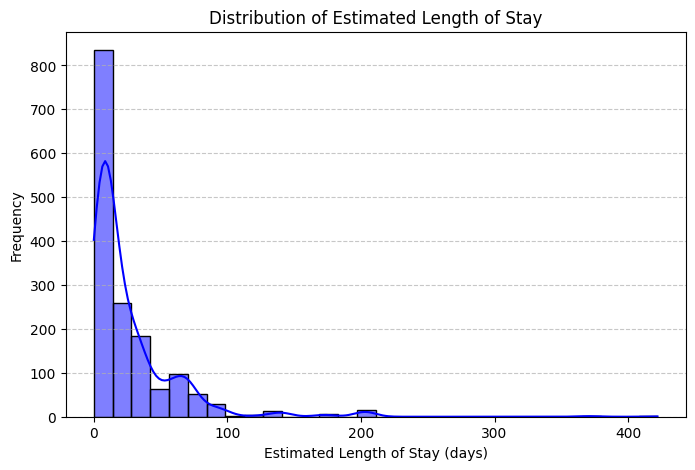

In [20]:
# Plot histogram of estimated_los, ignoring NaN values
plt.figure(figsize=(8, 5))
sns.histplot(tsqic_merged_filtered['estimated_los'].dropna(), bins=30, kde=True, color='blue')

# Add labels and title
plt.xlabel('Estimated Length of Stay (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Length of Stay')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [21]:
tsqic_merged_filtered

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,estimated_los
0,37,2023-05-03,NaN,NaN,NaN,NaN,2023-05-06,3.0
1,44,2019-05-21,NaN,NaN,NaN,NaN,2019-05-23,2.0
2,55,2019-10-22,NaN,NaN,NaN,NaN,2019-10-28,6.0
3,76,2021-05-18,Ileus,2.0,II - New Medication,0.0,2021-05-25,7.0
4,78,2019-09-03,NaN,NaN,NaN,NaN,2020-09-10,373.0
...,...,...,...,...,...,...,...,...
1928,1722,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03,7.0
1929,1722,2024-08-27,Atelactasis,2.0,II - New Medication,0.0,2024-09-03,7.0
1930,1722,2024-08-27,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03,7.0
1931,1748,2024-08-13,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30,17.0


In [22]:
tsqic_merged_filtered = tsqic_merged_filtered.drop_duplicates()
tsqic_merged_filtered


,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,estimated_los
0,37,2023-05-03,NaN,NaN,NaN,NaN,2023-05-06,3.0
1,44,2019-05-21,NaN,NaN,NaN,NaN,2019-05-23,2.0
2,55,2019-10-22,NaN,NaN,NaN,NaN,2019-10-28,6.0
3,76,2021-05-18,Ileus,2.0,II - New Medication,0.0,2021-05-25,7.0
4,78,2019-09-03,NaN,NaN,NaN,NaN,2020-09-10,373.0
...,...,...,...,...,...,...,...,...
1928,1722,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03,7.0
1929,1722,2024-08-27,Atelactasis,2.0,II - New Medication,0.0,2024-09-03,7.0
1930,1722,2024-08-27,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03,7.0
1931,1748,2024-08-13,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30,17.0


In [23]:
# Save to a new Excel file
tsqic_merged_filtered.to_excel("Merged_TSQIC.xlsx", index=False)

# REDCap merging

In [24]:
# Read the CSV file - emotional distress 
file_path = "EsophagealBank-EsoData19Aug2025_DATA_2025-08-20_1152.csv"
df_redcap = pd.read_csv(file_path)
df_redcap

,id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,sx_date,recurrence,recurrence_date,recurrence_location___local,recurrence_location___regional,recurrence_location___distant,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
0,1,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,5_years_postop_arm_1,NaN,NaN,NaN,999.0,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,surgery_arm_1,surgery_esd_emr,1.0,9/13/06,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,1,surgery_arm_1,surgical_pathology,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,surgery_arm_1,postoperative_course,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13296,1800,baseline_arm_1,cstaging_and_diagnosis,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13297,1801,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13298,1801,baseline_arm_1,functional_assessment_of_cancer_therapy_fact_e...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,2.0,3.0,17.0,56.0,96.0,NaN,2.0,NaN
13299,1802,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# df_redcap['id'] = df_redcap['id'].astype(int)
# df_update_1['Patient ID'] = df_update_1['Patient ID'].astype(int)

# Create a mapping dictionary from df_update_1
update_mapping = df_update_1.set_index('Patient ID')['icu admission'].to_dict()

# Update df_redcap using map function
df_redcap['icu_duration'] = df_redcap['id'].map(update_mapping).fillna(df_redcap['icu_duration'])

In [26]:
df = df_redcap.copy()

# Convert sx_date to string to handle NaNs uniformly
df['sx_date'] = df['sx_date'].astype(str)

# Find ids with all sx_date missing or empty
no_sx_date_ids = df.groupby('id')['sx_date'].apply(lambda x: all((v.strip() == '' or v.lower() == 'nan') for v in x))

# Count how many such ids there are
count_no_sx_date = no_sx_date_ids.sum()

print("Number of patient IDs with no sx_date at all:", count_no_sx_date)


Number of patient IDs with no sx_date at all: 546


In [27]:
df_redcap['id'].nunique()

1787

In [28]:
df_redcap['id'].nunique()

1787

In [29]:
columns = ['dod', 'last_fu_date', 'recurrence', 'recurrence_location___distant', 'recurrence_location___ukn', 'dfs', 'dfs_2', 'icu_duration']

for col in columns:
    print(f"\n=== {col.upper()} ===")
    freq = (
        df_redcap[df_redcap[col].notna()]
        .groupby('redcap_event_name')
        .size()
        .reset_index(name='count')
    )
    freq['percent'] = 100 * freq['count'] / freq['count'].sum()
    print(freq.sort_values('count', ascending=False))



=== DOD ===
      redcap_event_name  count  percent
0  5_years_postop_arm_1    812    100.0

=== LAST_FU_DATE ===
      redcap_event_name  count    percent
2  5_years_postop_arm_1   1256  99.053628
0  1_month_postop_arm_1     11   0.867508
1   1_year_postop_arm_1      1   0.078864

=== RECURRENCE ===
      redcap_event_name  count    percent
1  5_years_postop_arm_1    956  99.273105
0  1_month_postop_arm_1      7   0.726895

=== RECURRENCE_LOCATION___DISTANT ===
      redcap_event_name  count  percent
0  5_years_postop_arm_1   1569    100.0

=== RECURRENCE_LOCATION___UKN ===
      redcap_event_name  count  percent
0  5_years_postop_arm_1   1569    100.0

=== DFS ===
      redcap_event_name  count  percent
0  5_years_postop_arm_1    988    100.0

=== DFS_2 ===
      redcap_event_name  count  percent
0  5_years_postop_arm_1    261    100.0

=== ICU_DURATION ===
        redcap_event_name  count    percent
10          surgery_arm_1    462  29.748873
8          baseline_arm_1    340  21.89

In [30]:
df_redcap = df_redcap[df_redcap['redcap_event_name'].isin(['surgery_arm_1', '1_month_postop_arm_1', '5_years_postop_arm_1'])]
df_redcap

,id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,sx_date,recurrence,recurrence_date,recurrence_location___local,recurrence_location___regional,recurrence_location___distant,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
1,1,5_years_postop_arm_1,NaN,NaN,NaN,999.0,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,surgery_arm_1,surgery_esd_emr,1.0,9/13/06,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,1,surgery_arm_1,surgical_pathology,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,surgery_arm_1,postoperative_course,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2,1_month_postop_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13272,1794,5_years_postop_arm_1,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13278,1795,surgery_arm_1,surgery_esd_emr,1.0,7/30/25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
13283,1796,surgery_arm_1,surgery_esd_emr,1.0,7/30/25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13286,1797,surgery_arm_1,surgery_esd_emr,1.0,7/23/25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [31]:
#Column name change before merged 
df_redcap = df_redcap.rename(columns={"sx_date": "operation_date"})

#convert to datetime
df_redcap['operation_date'] = pd.to_datetime(df_redcap['operation_date'], errors='coerce')  

/tmp/ipykernel_1760481/2138582727.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_redcap['operation_date'] = pd.to_datetime(df_redcap['operation_date'], errors='coerce')


In [32]:
#Validate the number of unique ids and redcap_event_name.
print(df_redcap["id"].nunique())
df_redcap.drop_duplicates()

1609


,id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,operation_date,recurrence,recurrence_date,recurrence_location___local,recurrence_location___regional,recurrence_location___distant,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
1,1,5_years_postop_arm_1,NaN,NaN,NaT,999.0,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,surgery_arm_1,surgery_esd_emr,1.0,2006-09-13,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,1,surgery_arm_1,surgical_pathology,1.0,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,surgery_arm_1,postoperative_course,1.0,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2,1_month_postop_arm_1,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13272,1794,5_years_postop_arm_1,NaN,NaN,NaT,NaN,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13278,1795,surgery_arm_1,surgery_esd_emr,1.0,2025-07-30,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
13283,1796,surgery_arm_1,surgery_esd_emr,1.0,2025-07-30,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13286,1797,surgery_arm_1,surgery_esd_emr,1.0,2025-07-23,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [33]:
df_redcap.to_excel("Merged_REDCap.xlsx", index=False)

# TSQIC REDCap_FactE merging

In [34]:
#Create a copy of merged_matched
merged_tsqic = tsqic_merged_filtered.copy()

#Rename estimated_los to los to match collapsed_redcap
merged_tsqic = merged_tsqic.rename(columns={'estimated_los': 'los'})
merged_tsqic['id'] = merged_tsqic['id'].astype(str)

merged_tsqic

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los
0,37,2023-05-03,NaN,NaN,NaN,NaN,2023-05-06,3.0
1,44,2019-05-21,NaN,NaN,NaN,NaN,2019-05-23,2.0
2,55,2019-10-22,NaN,NaN,NaN,NaN,2019-10-28,6.0
3,76,2021-05-18,Ileus,2.0,II - New Medication,0.0,2021-05-25,7.0
4,78,2019-09-03,NaN,NaN,NaN,NaN,2020-09-10,373.0
...,...,...,...,...,...,...,...,...
1928,1722,2024-08-27,Effusion,2.0,II - New Medication,0.0,2024-09-03,7.0
1929,1722,2024-08-27,Atelactasis,2.0,II - New Medication,0.0,2024-09-03,7.0
1930,1722,2024-08-27,Difficulty breathing,2.0,II - New Medication,0.0,2024-09-03,7.0
1931,1748,2024-08-13,Non Infectious Diarrhea,2.0,II - New Medication,0.0,2024-08-30,17.0


In [35]:
df_redcap['id'] = df_redcap['id'].astype(str)
df_redcap

,id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,operation_date,recurrence,recurrence_date,recurrence_location___local,recurrence_location___regional,recurrence_location___distant,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
1,1,5_years_postop_arm_1,NaN,NaN,NaT,999.0,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,surgery_arm_1,surgery_esd_emr,1.0,2006-09-13,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,1,surgery_arm_1,surgical_pathology,1.0,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,surgery_arm_1,postoperative_course,1.0,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2,1_month_postop_arm_1,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13272,1794,5_years_postop_arm_1,NaN,NaN,NaT,NaN,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13278,1795,surgery_arm_1,surgery_esd_emr,1.0,2025-07-30,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
13283,1796,surgery_arm_1,surgery_esd_emr,1.0,2025-07-30,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13286,1797,surgery_arm_1,surgery_esd_emr,1.0,2025-07-23,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [36]:
merged_df = merged_tsqic.merge(df_redcap, on=['id', 'operation_date'], how='outer')
merged_df

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
0,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,postoperative_course,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2006-09-13,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,10,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6679,997,2024-10-28,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6680,998,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6681,999,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6682,999,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [37]:
# Get unique (id, operation_date) pairs from each dataset
pairs_tsqic = set(merged_tsqic[['id']].apply(tuple, axis=1))
pairs_redcap = set(df_redcap[['id']].apply(tuple, axis=1))

# Find pairs that appear in both
pairs_in_both = pairs_tsqic & pairs_redcap

# Find pairs only in merged_tsqic
pairs_only_in_tsqic = pairs_tsqic - pairs_redcap

# Find pairs only in collapsed_redcap
pairs_only_in_redcap = pairs_redcap - pairs_tsqic

# Print the counts
print(f"redcap unique id: {df_redcap['id'].nunique()}")
print(f"tsqic unique id: {merged_tsqic['id'].nunique()}")

print(f"Pairs in both datasets: {len(pairs_in_both)}")
print(f"Pairs only in merged_tsqic: {len(pairs_only_in_tsqic)}")
print(f"Pairs only in collapsed_redcap: {len(pairs_only_in_redcap)}")

redcap unique id: 1609
tsqic unique id: 661
Pairs in both datasets: 644
Pairs only in merged_tsqic: 17
Pairs only in collapsed_redcap: 965


In [38]:
# Get unique IDs for pairs in both datasets
ids_in_both = {pair[0] for pair in pairs_in_both}

# Get unique IDs only in df_redcap
ids_only_in_redcap = {pair[0] for pair in pairs_only_in_redcap}

# Get unique IDs only in df_redcap
ids_only_in_tsqic = {pair[0] for pair in pairs_only_in_tsqic}

# Convert to sorted lists for better readability
ids_in_both_list = sorted(ids_in_both)
ids_only_in_redcap_list = sorted(ids_only_in_redcap)
ids_only_in_tsqic_list = sorted(ids_only_in_tsqic)

# Print results
print("IDs in both datasets:", ids_in_both_list)
print("IDs only in df_redcap:", ids_only_in_redcap_list)
print("IDs only in tsqic:", ids_only_in_tsqic_list)

IDs in both datasets: ['1000', '1001', '1002', '1003', '1004', '1009', '1010', '1012', '1013', '1014', '1015', '1016', '1017', '1018', '1019', '102', '1020', '1021', '1022', '1023', '1024', '1026', '1029', '1031', '1032', '1033', '1038', '1039', '1041', '1043', '1045', '1046', '1047', '1048', '1049', '1050', '1051', '1052', '1053', '1054', '1056', '1061', '1062', '1063', '1068', '1070', '1071', '1073', '1075', '1076', '1077', '1078', '1080', '1082', '1086', '1087', '1092', '1100', '1101', '1102', '1103', '1104', '1109', '1110', '1111', '1113', '1120', '1121', '1122', '1127', '1130', '1132', '1133', '1134', '1135', '1136', '1138', '1141', '1142', '1143', '1145', '1148', '1149', '1150', '1151', '1155', '1156', '1158', '1162', '1164', '1165', '1166', '1167', '1168', '1172', '1173', '1175', '1176', '1179', '1180', '1182', '1183', '1184', '1186', '1187', '1188', '1189', '1190', '1191', '1192', '1195', '1198', '1199', '1205', '1206', '1208', '1209', '1210', '1212', '1213', '1214', '1215', '1

In [39]:
non_null_counts = merged_df.notna().sum(axis=1)

# Find rows where only one column is filled - for sanitary check
merged_df[non_null_counts == 1]

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment


In [40]:
# Find rows where 'los' is not null but 'operation_date' or 'ComplicationDate' is missing -> most likely another row has duplicated operation_date and complication date.
missing_dates_rows = merged_df[(merged_df['los'].notna()) & 
                            (merged_df['operation_date'].isna() | merged_df['DischargeDate'].isna())]

# Select relevant columns (row number and id)
result = missing_dates_rows[['id']].copy()
result['row_number'] = missing_dates_rows.index

result


,id,row_number


In [41]:
# Number of rows where 'los' is duplicated within the same 'id' (ignoring NaN):  479 rows (2 or 3 duplicates) -> 0 
# Set all but one 'los' value to NaN for each duplicated group
# Create a mask for non-null 'los' values and check duplicates within each 'id'
valid_mask = merged_df['los'].notna()  # Ignore NaN values
duplicated_mask = merged_df.loc[valid_mask].duplicated(subset=['id', 'los'], keep=False)

# Re-align the mask with the original DataFrame (fill missing indexes with False)
full_mask = valid_mask.copy()
full_mask.loc[valid_mask] = duplicated_mask  

# Save the rows that will be modified (optional for debugging or checking)
duplicate_rows = merged_df.loc[full_mask].copy()  

# Set all but one 'los' value to NaN for each (id, los) pair, keeping one of each unique los value
merged_df.loc[full_mask, 'los'] = merged_df.loc[full_mask].groupby(['id', 'los'])['los'].transform(lambda x: [x.iloc[0]] + [float('nan')] * (len(x) - 1))

# Display results
print(f"Number of rows where 'los' was modified: {full_mask.sum()}")

Number of rows where 'los' was modified: 985


In [42]:
#Number of rows where 'operation_date' is duplicated within the same 'id' (ignoring NaN):  98 rows (2 duplicates) -> 0
# Set all but one 'operation_date' value to NaN for each duplicated group
# Create a mask for non-null 'operation_date' values and check duplicates within each 'id'
valid_mask = merged_df['operation_date'].notna()  # Ignore NaN values
duplicated_mask = merged_df.loc[valid_mask].duplicated(subset=['id', 'operation_date'], keep=False)

# Re-align the mask with the original DataFrame (fill missing indexes with False)
full_mask = valid_mask.copy()
full_mask.loc[valid_mask] = duplicated_mask  

# Save the rows that will be modified (optional for debugging or checking)
duplicate_rows = merged_df.loc[full_mask].copy()  


# Create a temporary Series to mark which values to keep (first occurrence = True, others = False)
keep_first = ~merged_df.loc[full_mask].duplicated(subset=['id', 'operation_date'], keep='first')

# Make a copy of the operation_date column
temp_dates = merged_df['operation_date'].copy()

# Set all duplicated dates (except first occurrence) to NaN
temp_dates.loc[full_mask] = temp_dates.loc[full_mask].where(keep_first, pd.NaT)

# Assign back to the dataframe
merged_df['operation_date'] = temp_dates

# Display results
print(f"Number of rows where 'operation_date' was modified: {full_mask.sum() - keep_first.sum()}")



# # Set all but one 'operation_date' value to NaN for each (id, operation_date) pair, keeping one of each unique operation_date value
# merged_df.loc[full_mask, 'operation_date'] = merged_df.loc[full_mask].groupby(['id', 'operation_date'])['operation_date'].transform(lambda x: [x.iloc[0]] + [float('nan')] * (len(x) - 1))

# # Display results
# print(f"Number of rows where 'operation_date' was modified: {full_mask.sum()}")


Number of rows where 'operation_date' was modified: 829


In [43]:
# Number of rows where 'readmission_30d' is duplicated within the same 'id' (ignoring NaN): 246 rows (2 3 6 duplicates) -> 0
# Set all but one 'readmission_30d' value to NaN for each duplicated group
# Create a mask for non-null 'readmission_30d' values and check duplicates within each 'id'
valid_mask = merged_df['readmission_30d'].notna()  # Ignore NaN values
duplicated_mask = merged_df.loc[valid_mask].duplicated(subset=['id', 'readmission_30d'], keep=False)

# Re-align the mask with the original DataFrame (fill missing indexes with False)
full_mask = valid_mask.copy()
full_mask.loc[valid_mask] = duplicated_mask  

# Save the rows that will be modified (optional for debugging or checking)
duplicate_rows = merged_df.loc[full_mask].copy()  

# Set all but one 'readmission_30d' value to NaN for each (id, readmission_30d) pair, keeping one of each unique readmission_30d value
merged_df.loc[full_mask, 'readmission_30d'] = merged_df.loc[full_mask].groupby(['id', 'readmission_30d'])['readmission_30d'].transform(lambda x: [x.iloc[0]] + [float('nan')] * (len(x) - 1))

# Display results
print(f"Number of rows where 'readmission_30d' was modified: {full_mask.sum()}")

Number of rows where 'readmission_30d' was modified: 1192


In [44]:
#Number of rows where 'DischargeDate' is duplicated within the same 'id' (ignoring NaN): 478 rows (2 or 3 duplicates) -> 0
# Set all but one 'DischargeDate' value to NaN for each duplicated group
# Create a mask for non-null 'DischargeDate' values and check duplicates within each 'id'
valid_mask = merged_df['DischargeDate'].notna()  # Ignore NaN values
duplicated_mask = merged_df.loc[valid_mask].duplicated(subset=['id', 'DischargeDate'], keep=False)

# Re-align the mask with the original DataFrame (fill missing indexes with False)
full_mask = valid_mask.copy()
full_mask.loc[valid_mask] = duplicated_mask  

# Save the rows that will be modified (optional for debugging or checking)
duplicate_rows = merged_df.loc[full_mask].copy()  

# Set all but one 'DischargeDate' value to NaN for each (id, DischargeDate) pair, keeping one of each unique DischargeDate value
merged_df.loc[full_mask, 'DischargeDate'] = merged_df.loc[full_mask].groupby(['id', 'DischargeDate'])['DischargeDate'].transform(lambda x: [x.iloc[0]] + [float('nan')] * (len(x) - 1))

# Display results
print(f"Number of rows where 'DischargeDate' was modified: {full_mask.sum()}")


Number of rows where 'DischargeDate' was modified: 956


In [45]:
merged_df

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
0,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,postoperative_course,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2006-09-13,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,10,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6679,997,2024-10-28,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6680,998,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6681,999,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6682,999,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [46]:
merged_df['id'] = merged_df['id'].astype(int)
merged_df

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
0,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,postoperative_course,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2006-09-13,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,10,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6679,997,2024-10-28,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6680,998,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6681,999,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6682,999,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [47]:
#sort based on id.
merged_df = merged_df.sort_values(by='id')
merged_df

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete,expectation_treatment
0,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,postoperative_course,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2006-09-13,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3215,2,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3128,1794,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3129,1795,2025-07-30,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3130,1796,2025-07-30,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3131,1797,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
merged_final = merged_df.copy()
# Save to a new Excel file
merged_final.to_excel("Merged_TSQIC_REDCap.xlsx", index=False)